# `CellStratifiedKFold`

`CellStratifiedKFold` partitions observations into k folds so that every
fold receives a **proportionally representative mix** of observations from
across the study area.

Each observation is assigned to a **Discrete Global Grid System (DGGS)** tile
(H3 hexagon by default, or HEALPix / A5 / S2).  Tile membership becomes the
stratum label for a standard `StratifiedKFold` split, so every fold gets a
similar share of observations from every occupied tile.

The resolution is **auto-detected** by scanning from coarse to fine until at
least `n_splits` tiles are occupied.  You can also pass `resolution` directly.
At H3 resolution 5, tiles are roughly 250 km^2 — large enough to capture
coarse regional structure without over-fragmenting small datasets.


In [1]:
import numpy
import geopandas
import geodatasets
import colormaps
import shapely
import h3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import cdist
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

from spml.validation import CellStratifiedKFold

/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Small example — Chicago community areas

Chicago's 77 community areas are small enough to see the tile structure clearly.
At H3 resolution 5 the city is covered by 8 tiles; the auto-detector picks this
resolution because it is the coarsest level with at least 5 occupied tiles.


In [2]:
chicago = geopandas.read_file(geodatasets.get_path('geoda.chicago_health')).to_crs('EPSG:32616')
chicago['income'] = chicago['PerCInc14'].fillna(chicago['PerCInc14'].median())
print(f'n = {len(chicago)} community areas')

N_SPLITS = 5
# shuffle=True randomises within-cell fold assignment; without it, observations
# are assigned in row order, which can produce geographic clustering if the
# dataset has a spatial sort (common in GeoDataFrames).
cellcv = CellStratifiedKFold(n_splits=N_SPLITS, grid='h3', shuffle=True, random_state=0)
splits = list(cellcv.split(chicago))

print(f'Auto-detected H3 resolution: {cellcv.resolution_}')
print(f'Unique tiles occupied: {len(set(cellcv.cell_ids_))}')
print(f'Fold sizes: {[len(t) for _, t in splits]}')

n = 77 community areas
Auto-detected H3 resolution: 5
Unique tiles occupied: 8
Fold sizes: [16, 16, 15, 15, 15]


/Users/lw17329/Dropbox/work/dev/geovalidate/src/geovalidate/cv/_cell_stratified_kfold.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts = geom.centroid
/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


### Tile assignment and fold map

The left panel shows each community area coloured by the H3 tile it belongs to.
The hexagonal tile boundaries are overlaid in grey.  The right panel shows the
resulting 5-fold assignment: each fold receives observations from multiple tiles.


/var/folders/l2/x261scsn70z33pvfm0bycvnh0000gp/T/ipykernel_93869/3874348438.py:50: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Fold', fontsize=8, loc='lower right')
/var/folders/l2/x261scsn70z33pvfm0bycvnh0000gp/T/ipykernel_93869/3874348438.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Fold', fontsize=8, loc='lower right')


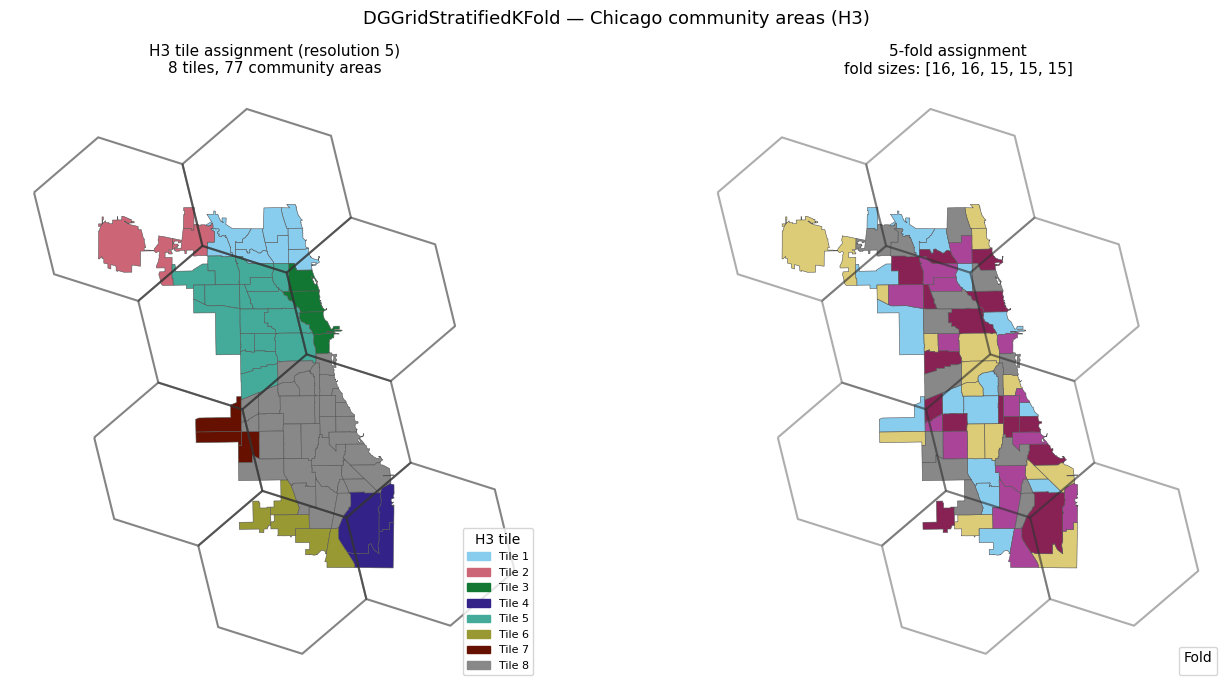

In [3]:
# Build H3 hex polygons for the occupied tiles
unique_cells = list(set(cellcv.cell_ids_))
hex_polys, hex_ids = [], []
for cell in unique_cells:
    bnd = h3.cell_to_boundary(cell)           # list of (lat, lon)
    coords = [(lon, lat) for lat, lon in bnd]
    hex_polys.append(shapely.Polygon(coords))
    hex_ids.append(cell)
hexgdf = geopandas.GeoDataFrame({'cell': hex_ids, 'geometry': hex_polys},
                                crs='EPSG:4326').to_crs('EPSG:32616')

# Map cell IDs to integers for colouring
cell_to_int = {c: i for i, c in enumerate(unique_cells)}
chicago['tile_int'] = [cell_to_int[c] for c in cellcv.cell_ids_]

# Fold labels
fold_labels = numpy.full(len(chicago), -1, dtype=int)
for fi, (_, test) in enumerate(splits):
    fold_labels[test] = fi
chicago['fold'] = fold_labels

n_tiles = len(unique_cells)
tile_colors = [colormaps.safe(i / max(n_tiles - 1, 1)) for i in range(n_tiles)]
fold_colors = [colormaps.safe(i / (N_SPLITS - 1)) for i in range(N_SPLITS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: tile assignment with hex boundaries
ax = axes[0]
for ti in range(n_tiles):
    chicago[chicago.tile_int == ti].plot(ax=ax, color=tile_colors[ti],
                                         edgecolor='#555', linewidth=0.4)
hexgdf.boundary.plot(ax=ax, color='#333', linewidth=1.5, alpha=0.6)
tile_patches = [
    mpatches.Patch(color=tile_colors[i], label=f'Tile {i+1}')
    for i in range(n_tiles)
]
ax.legend(handles=tile_patches, title='H3 tile', fontsize=8, loc='lower right')
ax.set_title(f'H3 tile assignment (resolution {cellcv.resolution_})\n'
             f'{n_tiles} tiles, {len(chicago)} community areas', fontsize=11)
ax.axis('off')

# Right: fold assignment
ax = axes[1]
for fi in range(N_SPLITS):
    chicago[chicago.fold == fi].plot(ax=ax, color=fold_colors[fi],
                                     edgecolor='#555', linewidth=0.4,
                                     label=f'Fold {fi+1}')
hexgdf.boundary.plot(ax=ax, color='#333', linewidth=1.5, alpha=0.4)
ax.legend(title='Fold', fontsize=8, loc='lower right')
ax.set_title(f'5-fold assignment\n'
             f'fold sizes: {[len(t) for _, t in splits]}', fontsize=11)
ax.axis('off')

fig.suptitle('CellStratifiedKFold — Chicago community areas (H3)', fontsize=13)
fig.tight_layout()
plt.show()

### Geographic balance check

Each fold should sample from all parts of the city.  The panel below
shows the 5 test folds individually; each fold covers most tiles.


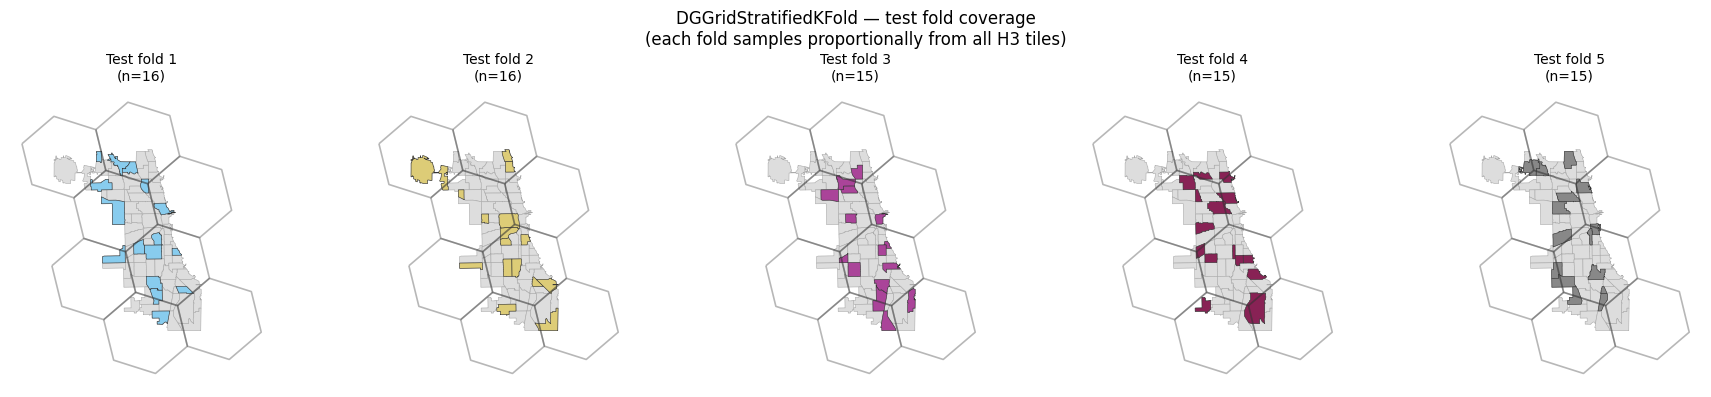

In [4]:
fig, axes = plt.subplots(1, N_SPLITS, figsize=(18, 4),
                         subplot_kw={'aspect': 'equal'})
for fi in range(N_SPLITS):
    ax = axes[fi]
    chicago.plot(ax=ax, color='#ddd', edgecolor='#aaa', linewidth=0.4)
    chicago[chicago.fold == fi].plot(ax=ax, color=fold_colors[fi],
                                     edgecolor='#333', linewidth=0.4)
    hexgdf.boundary.plot(ax=ax, color='#333', linewidth=1.2, alpha=0.35)
    ax.set_title(f'Test fold {fi+1}\n(n={int((chicago.fold==fi).sum())})', fontsize=10)
    ax.axis('off')

fig.suptitle('CellStratifiedKFold — test fold coverage\n'
             '(each fold samples proportionally from all H3 tiles)', fontsize=12)
fig.tight_layout()
plt.show()

## Large example — King County house sales (600 points)

With a larger, irregular point dataset the geographic balance benefit of
`CellStratifiedKFold` becomes clearer.  We compare it against a plain
`KFold` (no spatial structure) on three metrics:

1. **Fold map** — where each fold's test points fall
2. **Within-fold geographic spread** — mean nearest-neighbour distance
   within each test fold (higher = better coverage of the study area)
3. **Fold RMSE** — predicting log(price) from structural features;
   lower fold-to-fold variance = more reliable CV estimates


In [5]:
gdf_full = geopandas.read_file(geodatasets.get_path('geoda.home_sales')).to_crs('EPSG:32610')
gdf_full['log_price'] = numpy.log(gdf_full['price'])
gdf_full['decile'] = (
    gdf_full['log_price'].rank(pct=True).multiply(10).clip(upper=9.99).astype(int)
)
idx = (
    gdf_full.groupby('decile')
    .apply(lambda g: g.sample(min(60, len(g)), random_state=42), include_groups=False)
    .index.get_level_values(1)
)
gdf = gdf_full.loc[idx].reset_index(drop=True)
print(f'n = {len(gdf)} sales  |  price ${gdf.price.min():,.0f} -- ${gdf.price.max():,.0f}')

n = 600 sales  |  price $84,000 -- $3,168,750


In [6]:
N_SPLITS5 = 5
feat_cols = ['sqft_liv', 'bedrooms', 'bathrooms', 'grade']
y5 = numpy.log(gdf['price'].values)
X5 = gdf[feat_cols].fillna(0).values
coords5 = numpy.column_stack([gdf.geometry.x, gdf.geometry.y])

cellcv5 = CellStratifiedKFold(n_splits=N_SPLITS5, grid='h3', shuffle=True, random_state=0)
rkf5   = KFold(n_splits=N_SPLITS5, shuffle=True, random_state=0)

dgg_splits = list(cellcv5.split(gdf))
rnd_splits = list(rkf5.split(X5))

# Fold labels for map
dgg_labels = numpy.full(len(gdf), -1, dtype=int)
for fi, (_, test) in enumerate(dgg_splits):
    dgg_labels[test] = fi
rnd_labels = numpy.full(len(gdf), -1, dtype=int)
for fi, (_, test) in enumerate(rnd_splits):
    rnd_labels[test] = fi
gdf['dgg_fold'] = dgg_labels
gdf['rnd_fold'] = rnd_labels

print(f'H3 resolution: {cellcv5.resolution_}, tiles: {len(set(cellcv5.cell_ids_))}')
print(f'DGGrid fold sizes: {[len(t) for _, t in dgg_splits]}')
print(f'Random fold sizes: {[len(t) for _, t in rnd_splits]}')

H3 resolution: 4, tiles: 6
DGGrid fold sizes: [120, 120, 120, 120, 120]
Random fold sizes: [120, 120, 120, 120, 120]


/Users/lw17329/Dropbox/work/dev/geovalidate/src/geovalidate/cv/_cell_stratified_kfold.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts = geom.centroid
/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [7]:
def mean_nn(splits, coords):
    means = []
    for _, test in splits:
        c = coords[test]
        D = cdist(c, c); numpy.fill_diagonal(D, numpy.inf)
        means.append(D.min(axis=1).mean())
    return means


dgg_nn = mean_nn(dgg_splits, coords5)
rnd_nn = mean_nn(rnd_splits, coords5)

dgg_rmse, rnd_rmse = [], []
for train, test in dgg_splits:
    lr = LinearRegression().fit(X5[train], y5[train])
    dgg_rmse.append(root_mean_squared_error(y5[test], lr.predict(X5[test])))
for train, test in rnd_splits:
    lr = LinearRegression().fit(X5[train], y5[train])
    rnd_rmse.append(root_mean_squared_error(y5[test], lr.predict(X5[test])))

print(f'DGGrid mean within-fold NN: {numpy.mean(dgg_nn)/1000:.2f} km')
print(f'Random mean within-fold NN: {numpy.mean(rnd_nn)/1000:.2f} km')
print(f'DGGrid mean RMSE: {numpy.mean(dgg_rmse):.4f}  std: {numpy.std(dgg_rmse):.4f}')
print(f'Random mean RMSE: {numpy.mean(rnd_rmse):.4f}  std: {numpy.std(rnd_rmse):.4f}')

DGGrid mean within-fold NN: 1.97 km
Random mean within-fold NN: 1.86 km
DGGrid mean RMSE: 0.3625  std: 0.0281
Random mean RMSE: 0.3659  std: 0.0268


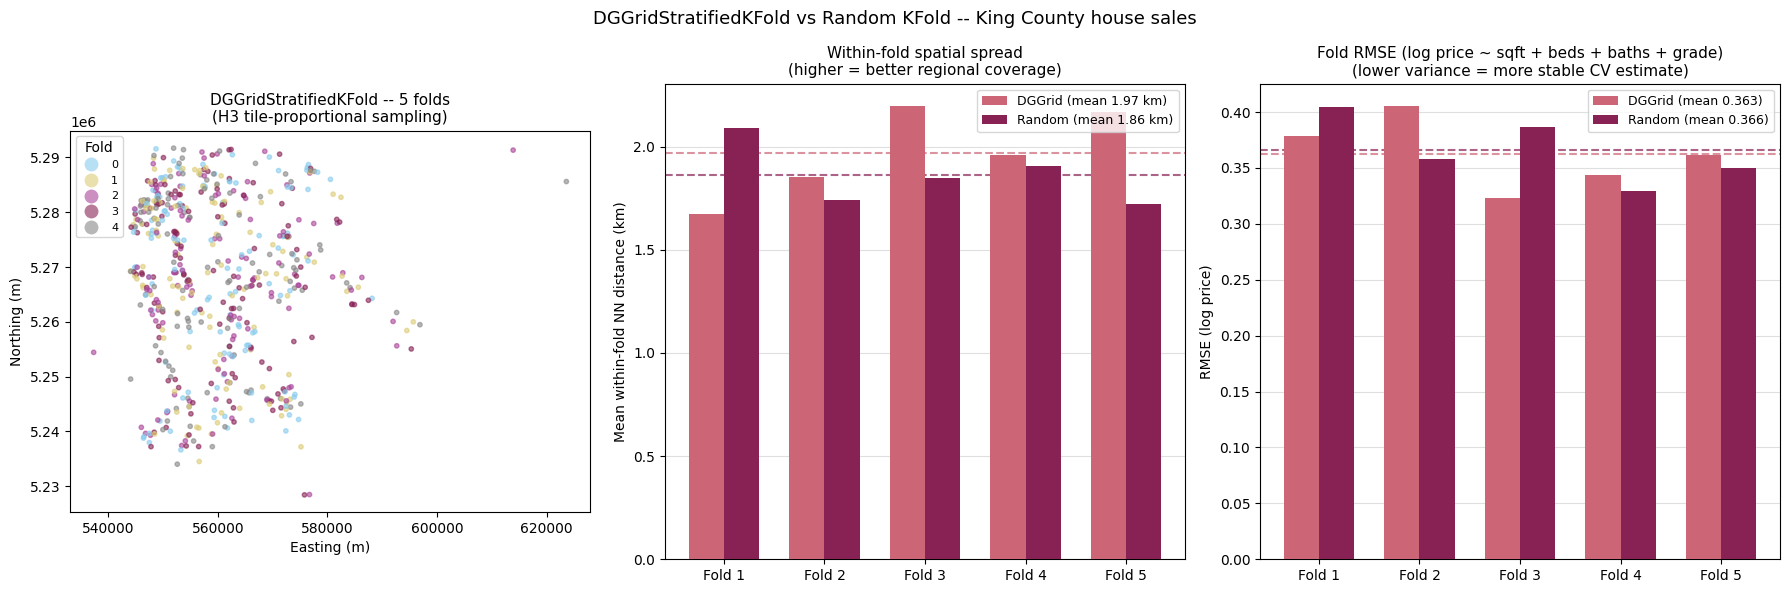

In [8]:
c_dgg = colormaps.safe(0.15)
c_rnd = colormaps.safe(0.75)
fold_colors5 = [colormaps.safe(i / (N_SPLITS5 - 1)) for i in range(N_SPLITS5)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1 -- fold map
gdf.plot(column='dgg_fold', cmap=colormaps.safe, categorical=True,
         markersize=10, alpha=0.6, legend=True,
         legend_kwds={'title': 'Fold', 'markerscale': 1, 'fontsize': 8},
         ax=axes[0])
axes[0].set_title('CellStratifiedKFold -- 5 folds\n'
                  '(H3 tile-proportional sampling)', fontsize=11)
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].set_aspect('equal')

# Panel 2 -- within-fold NN
x_pos = numpy.arange(N_SPLITS5); w = 0.35
ax2 = axes[1]
ax2.bar(x_pos - w/2, [d/1000 for d in dgg_nn], w, color=c_dgg, zorder=3,
        label=f'DGGrid (mean {numpy.mean(dgg_nn)/1000:.2f} km)')
ax2.bar(x_pos + w/2, [d/1000 for d in rnd_nn],  w, color=c_rnd, zorder=3,
        label=f'Random (mean {numpy.mean(rnd_nn)/1000:.2f} km)')
ax2.axhline(numpy.mean(dgg_nn)/1000, color=c_dgg, lw=1.5, ls='--', alpha=0.7)
ax2.axhline(numpy.mean(rnd_nn)/1000,  color=c_rnd, lw=1.5, ls='--', alpha=0.7)
ax2.set_xticks(x_pos); ax2.set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS5)])
ax2.set_ylabel('Mean within-fold NN distance (km)')
ax2.set_title('Within-fold spatial spread\n(higher = better regional coverage)', fontsize=11)
ax2.legend(fontsize=9); ax2.yaxis.grid(True, alpha=0.4); ax2.set_axisbelow(True)

# Panel 3 -- RMSE
ax3 = axes[2]
ax3.bar(x_pos - w/2, dgg_rmse, w, color=c_dgg, zorder=3,
        label=f'DGGrid (mean {numpy.mean(dgg_rmse):.3f})')
ax3.bar(x_pos + w/2, rnd_rmse, w, color=c_rnd, zorder=3,
        label=f'Random (mean {numpy.mean(rnd_rmse):.3f})')
ax3.axhline(numpy.mean(dgg_rmse), color=c_dgg, lw=1.5, ls='--', alpha=0.7)
ax3.axhline(numpy.mean(rnd_rmse),  color=c_rnd, lw=1.5, ls='--', alpha=0.7)
ax3.set_xticks(x_pos); ax3.set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS5)])
ax3.set_ylabel('RMSE (log price)')
ax3.set_title('Fold RMSE (log price ~ sqft + beds + baths + grade)\n'
              '(lower variance = more stable CV estimate)', fontsize=11)
ax3.legend(fontsize=9); ax3.yaxis.grid(True, alpha=0.4); ax3.set_axisbelow(True)

fig.suptitle('CellStratifiedKFold vs Random KFold -- King County house sales', fontsize=13)
fig.tight_layout()
plt.show()